---
---
---

<center>

# <b> IT3091 - Machine Learning </b> 
# <b> Lab Sheet 05 </b> 

#### Y3.S1.WD.AI.0101 
### IT24102699 - Mummullage B.U.T 

### <i> **Logistic Regression & k-Nearest Neighbors from Scratch** </i> 

</center>

---
---

## **Part A: Logistic Regression**

### **A.1 Dataset & Problem Setup**
A university wants to predict whether a student will Pass (1) or Fail (0) an examination based on the number of hours studied.

**Task 1:**
1. Create NumPy arrays for X and Y.
2. Display the dataset using a scatter plot.
3. Identify the input feature, target variable.

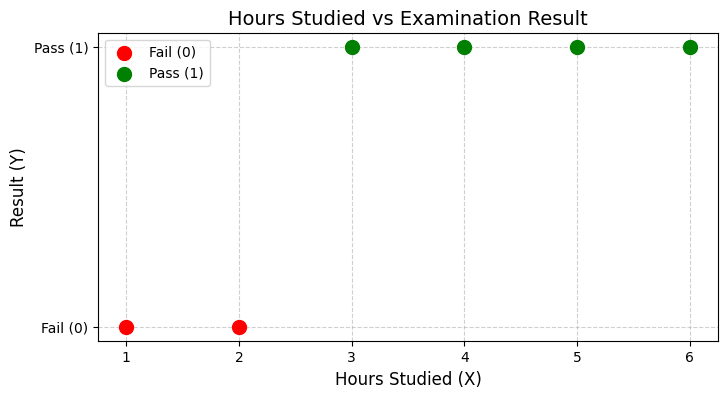

Input Feature (X): Hours Studied (Shape: (6, 1))
Target Variable (Y): Result - Pass/Fail (Shape: (6,))


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create NumPy arrays for X and Y
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
Y = np.array([0, 0, 1, 1, 1, 1])

# 2. Display the dataset using a scatter plot
plt.figure(figsize=(8, 4))
plt.scatter(X[Y == 0], Y[Y == 0], color='red', label='Fail (0)', s=100, zorder=3)
plt.scatter(X[Y == 1], Y[Y == 1], color='green', label='Pass (1)', s=100, zorder=3)
plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Result (Y)', fontsize=12)
plt.title('Hours Studied vs Examination Result', fontsize=14)
plt.yticks([0, 1], ['Fail (0)', 'Pass (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 3. Print feature identification
print(f"Input Feature (X): Hours Studied (Shape: {X.shape})")
print(f"Target Variable (Y): Result - Pass/Fail (Shape: {Y.shape})")

---


### **A.2 Sigmoid Function**
Logistic Regression calculates a linear score \(z = \theta_0 + \theta_1 x\) and converts it into a probability via the Sigmoid function:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Task 1:**
1. Implement the Sigmoid function from scratch using NumPy.
2. Initialize \(\theta_0 = 0\) and \(\theta_1 = 0\).
3. Calculate predicted probabilities for all observations.
4. What probability is produced for each observation at initial parameter values?
5. Why is the Sigmoid function required in Logistic Regression?

In [19]:
# 1. Implement Sigmoid function from scratch using NumPy
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Initialize theta0 = 0 and theta1 = 0
theta0 = 0.0
theta1 = 0.0

# 3. Calculate predicted probabilities for all observations
z_initial = theta0 + theta1 * X.flatten()
h_initial = sigmoid(z_initial)

print("Observation | Hours (X) | Target (Y) | Linear Score (z) | Predicted Prob h(x)")
print("-" * 75)
for i in range(len(X)):
    print(f"     {i+1:02d}     |     {X[i][0]}     |     {Y[i]}      |       {z_initial[i]:.2f}       |       {h_initial[i]:.4f}")

Observation | Hours (X) | Target (Y) | Linear Score (z) | Predicted Prob h(x)
---------------------------------------------------------------------------
     01     |     1     |     0      |       0.00       |       0.5000
     02     |     2     |     0      |       0.00       |       0.5000
     03     |     3     |     1      |       0.00       |       0.5000
     04     |     4     |     1      |       0.00       |       0.5000
     05     |     5     |     1      |       0.00       |       0.5000
     06     |     6     |     1      |       0.00       |       0.5000


---


### **A.3 Log-Loss / Binary Cross-Entropy**
Use the Binary Cross-Entropy cost function:
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(h_i) + (1 - y_i) \log(1 - h_i) \right]$$

**Task 1:**
1. Implement the Log-Loss function from scratch.
2. Calculate and display the initial cost.
3. What does a smaller Log-Loss value indicate?
4. What happens to the loss when the model confidently makes an incorrect prediction?
5. Why is a cost function required during model training?

In [43]:
# 1. Implement Log-Loss function from scratch
def compute_log_loss(X, Y, t0, t1):
    m = len(Y)
    z = t0 + t1 * X.flatten()
    h = sigmoid(z)
    eps = 1e-15  # Numerical stability against log(0)
    h = np.clip(h, eps, 1 - eps)
    loss = - (1 / m) * np.sum(Y * np.log(h) + (1 - Y) * np.log(1 - h))
    return loss

# 2. Calculate and display initial cost
initial_cost = compute_log_loss(X, Y, theta0, theta1)
print(f"Initial Log-Loss (theta0=0, theta1=0): {initial_cost:.4f}")

Initial Log-Loss (theta0=0, theta1=0): 0.6931


---


### **A.4 Gradient Descent**
Gradients:
$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h_i - y_i), \quad \frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (h_i - y_i) x_i$$
Update rule:
$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

**Task 1 – Train the Model:**
1. Set a suitable learning rate \(\alpha\) and initialize \(\theta_0 = 0, \theta_1 = 0\).
2. Calculate gradients.
3. Update parameters using Gradient Descent.
4. Repeat for a sufficient number of iterations.
5. Store cost at each iteration.
6. Display final values of \(\theta_0\) and \(\theta_1\).

**Task 2 – Observe Convergence:**
1. Plot iteration number against Log-Loss.
2. What happens to the loss as training progresses?
3. What does it mean when the loss begins to stabilize?
4. What could happen if the learning rate is too large?
5. What could happen if the learning rate is too small?

Training Complete (2000 iterations)
Final Parameter theta0 (Intercept): -12.5413
Final Parameter theta1 (Slope)    : 5.0927
Final Log-Loss Cost               : 0.0257


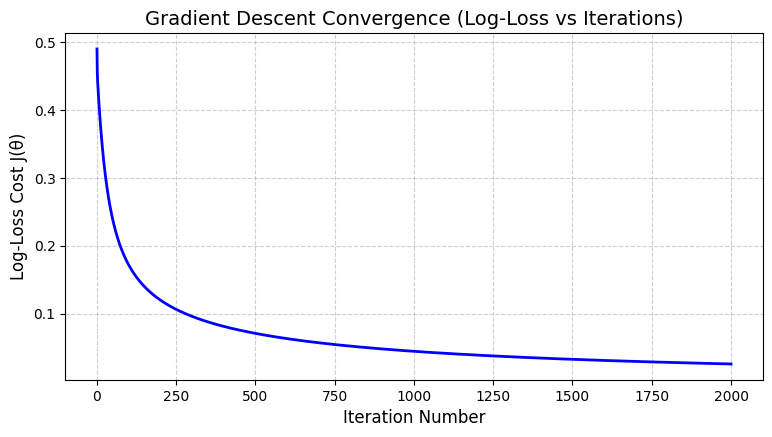

In [48]:
# Task 1: Train the Model using Gradient Descent
alpha = 0.5
num_iterations = 2000
m = len(Y)

t0 = 0.0
t1 = 0.0
cost_history = []

for i in range(num_iterations):
    z = t0 + t1 * X.flatten()
    h = sigmoid(z)
    
    # Calculate gradients
    grad_t0 = (1 / m) * np.sum(h - Y)
    grad_t1 = (1 / m) * np.sum((h - Y) * X.flatten())
    
    # Update parameters
    t0 = t0 - alpha * grad_t0
    t1 = t1 - alpha * grad_t1
    
    # Store cost
    cost = compute_log_loss(X, Y, t0, t1)
    cost_history.append(cost)

print(f"Training Complete ({num_iterations} iterations)")
print(f"Final Parameter theta0 (Intercept): {t0:.4f}")
print(f"Final Parameter theta1 (Slope)    : {t1:.4f}")
print(f"Final Log-Loss Cost               : {cost_history[-1]:.4f}")

# Task 2: Plot Convergence
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, num_iterations + 1), cost_history, color='blue', linewidth=2)
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Log-Loss Cost J(θ)', fontsize=12)
plt.title('Gradient Descent Convergence (Log-Loss vs Iterations)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---


### **A.5 Making Logistic Regression Predictions**
For a new observation: \(P(Y = 1 | X) = \sigma(\theta_0 + \theta_1 X)\).
Using threshold 0.5: \(\hat{y} = 1\) if \(P \ge 0.5\) else \(0\).

**Task:**
1. Create a prediction function from scratch.
2. Predict the result for a student who studies for 2.5 hours.
3. Display the predicted probability and predicted class.
4. Change the threshold from 0.5 to 0.7. Does the prediction change?
5. Explain the purpose of a classification threshold.

In [52]:
# 1. Create a prediction function from scratch
def predict(x_new, t0, t1, threshold=0.5):
    z = t0 + t1 * x_new
    prob = sigmoid(z)
    pred_class = 1 if prob >= threshold else 0
    return prob, pred_class

# 2 & 3. Predict for 2.5 hours at threshold 0.5
prob_25, class_05 = predict(2.5, t0, t1, threshold=0.5)

# 4. Predict for 2.5 hours at threshold 0.7
_, class_07 = predict(2.5, t0, t1, threshold=0.7)

print(f"Prediction for Student studying 2.5 hours:")
print(f" - Calculated Probability P(Y=1|X=2.5) : {prob_25:.4f} ({prob_25*100:.2f}%)")
print(f" - Predicted Class (Threshold = 0.5)   : {class_05} ({'Pass' if class_05 == 1 else 'Fail'})")
print(f" - Predicted Class (Threshold = 0.7)   : {class_07} ({'Pass' if class_07 == 1 else 'Fail'})")

Prediction for Student studying 2.5 hours:
 - Calculated Probability P(Y=1|X=2.5) : 0.5475 (54.75%)
 - Predicted Class (Threshold = 0.5)   : 1 (Pass)
 - Predicted Class (Threshold = 0.7)   : 0 (Fail)


---


### **A.6 Verify Logistic Regression Using Scikit-learn**

**Task:**
1. Train `LogisticRegression` using the same dataset.
2. Obtain the predicted probability and class for 2.5 hours.
3. Compare Scikit-learn result with from-scratch implementation.
4. Are the learned parameter values exactly the same? Discuss possible reasons for differences.

In [58]:
from sklearn.linear_model import LogisticRegression

# 1. Train LogisticRegression model
lr_model = LogisticRegression(penalty=None)
lr_model.fit(X, Y)

# 2. Predict for 2.5 hours
prob_sk = lr_model.predict_proba([[2.5]])[0][1]
class_sk = lr_model.predict([[2.5]])[0]

print("--- Scikit-Learn vs From-Scratch Comparison ---")
print(f"From-Scratch : Intercept (theta0) = {t0:.4f}, Coef (theta1) = {t1:.4f}")
print(f"Scikit-Learn : Intercept (theta0) = {lr_model.intercept_[0]:.4f}, Coef (theta1) = {lr_model.coef_[0][0]:.4f}")
print(f"From-Scratch (X=2.5): Prob = {prob_25:.4f}, Class = {class_05}")
print(f"Scikit-Learn (X=2.5): Prob = {prob_sk:.4f}, Class = {class_sk}")

--- Scikit-Learn vs From-Scratch Comparison ---
From-Scratch : Intercept (theta0) = -12.5413, Coef (theta1) = 5.0927
Scikit-Learn : Intercept (theta0) = -37.2169, Coef (theta1) = 14.9996
From-Scratch (X=2.5): Prob = 0.5475, Class = 1
Scikit-Learn (X=2.5): Prob = 0.5701, Class = 1


c:\Users\UsEr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


---
---

## **Part B: k-Nearest Neighbors (kNN)**

### **B.1 Problem Setup & B.2 Calculate Euclidean Distance**
Predict whether a student will Pass (1) or Fail (0) based on Hours Studied and Practice Tests Taken.
Query student: \(Q = (4, 2)\).

**Task (B.2):**
1. Create the training dataset using NumPy.
2. Implement Euclidean distance from scratch.
3. Calculate distance from Q to every training observation.
4. Display distances and sort observations from nearest to farthest.

In [64]:
# 1. Create training dataset using NumPy
X_train = np.array([
    [1.0, 1.0],   # Student A
    [2.0, 1.5],   # Student B
    [2.0, 3.0],   # Student C
    [4.0, 5.0],   # Student D
    [5.0, 4.5],   # Student E
    [5.0, 2.5]    # Student F
])
Y_train = np.array([0, 0, 0, 1, 1, 1])
student_names = ['A', 'B', 'C', 'D', 'E', 'F']
Q = np.array([4.0, 2.0])

# 2. Implement Euclidean distance from scratch
def euclidean_distance(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

# 3. Calculate distance from Q to every training observation
distance_list = []
for i in range(len(X_train)):
    dist = euclidean_distance(X_train[i], Q)
    distance_list.append({
        'Student': student_names[i],
        'Hours': X_train[i][0],
        'Tests': X_train[i][1],
        'Distance': dist,
        'Result': Y_train[i]
    })

# 4. Sort observations from nearest to farthest
sorted_distances = sorted(distance_list, key=lambda item: item['Distance'])

print("Distances to Query Point Q(4, 2), sorted nearest to farthest:\n")
print("Rank | Student | Hours | Tests | Distance to Q | Result Label")
print("-" * 60)
for rank, item in enumerate(sorted_distances, 1):
    res_str = 'Pass' if item['Result'] == 1 else 'Fail'
    print(f" {rank:02d}  |    {item['Student']}    |  {item['Hours']:.1f}  |  {item['Tests']:.1f}  |    {item['Distance']:.4f}    | {item['Result']} ({res_str})")

Distances to Query Point Q(4, 2), sorted nearest to farthest:

Rank | Student | Hours | Tests | Distance to Q | Result Label
------------------------------------------------------------
 01  |    F    |  5.0  |  2.5  |    1.1180    | 1 (Pass)
 02  |    B    |  2.0  |  1.5  |    2.0616    | 0 (Fail)
 03  |    C    |  2.0  |  3.0  |    2.2361    | 0 (Fail)
 04  |    E    |  5.0  |  4.5  |    2.6926    | 1 (Pass)
 05  |    D    |  4.0  |  5.0  |    3.0000    | 1 (Pass)
 06  |    A    |  1.0  |  1.0  |    3.1623    | 0 (Fail)


---


### **B.3 Find the k Nearest Neighbors & Majority Vote**

**Task:**
1. Set \(k = 3\).
2. Identify the three nearest observations.
3. Display their distances and class labels.
4. Apply majority voting.
5. Predict whether student Q will Pass or Fail.

In [71]:
# 1. Set k = 3
k = 3

# 2 & 3. Identify three nearest observations
top_k = sorted_distances[:k]

print(f"Top {k} Nearest Neighbors to Q(4, 2):")
for item in top_k:
    print(f" - Student {item['Student']}: Distance = {item['Distance']:.4f}, Class = {item['Result']}")

# 4. Apply majority voting
k_labels = [item['Result'] for item in top_k]
votes_fail = k_labels.count(0)
votes_pass = k_labels.count(1)
final_pred = 1 if votes_pass > votes_fail else 0

print(f"Majority Vote: Fail (0) = {votes_fail} votes, Pass (1) = {votes_pass} votes")
res_q_str = 'Pass' if final_pred == 1 else 'Fail'
print(f"Predicted Class for Q(4, 2): {final_pred} ({res_q_str})")

Top 3 Nearest Neighbors to Q(4, 2):
 - Student F: Distance = 1.1180, Class = 1
 - Student B: Distance = 2.0616, Class = 0
 - Student C: Distance = 2.2361, Class = 0
Majority Vote: Fail (0) = 2 votes, Pass (1) = 1 votes
Predicted Class for Q(4, 2): 0 (Fail)


---


### **B.4 Investigate the Effect of k**

**Task:**
1. Repeat prediction for \(k = 1, 3, 5\).
2. Record predicted class for each value of k.
3. Answer analytical questions on effect of k.

In [74]:
results = {}
for k_val in [1, 3, 5]:
    neighbors = sorted_distances[:k_val]
    labels = [item['Result'] for item in neighbors]
    pred = 1 if labels.count(1) > labels.count(0) else 0
    results[k_val] = 'Pass (1)' if pred == 1 else 'Fail (0)'
    print(f"k = {k_val} | Neighbors: {[n['Student'] for n in neighbors]} | Prediction: {results[k_val]}")

k = 1 | Neighbors: ['F'] | Prediction: Pass (1)
k = 3 | Neighbors: ['F', 'B', 'C'] | Prediction: Fail (0)
k = 5 | Neighbors: ['F', 'B', 'C', 'E', 'D'] | Prediction: Pass (1)


---


### **B.5 Visualize kNN**

**Task:**
1. Create a scatter plot with Hours Studied on X-axis and Practice Tests on Y-axis.
2. Use different markers or colors for Pass and Fail observations.
3. Plot the query point Q on the same graph.
4. Identify the nearest neighbors to Q for k=3.

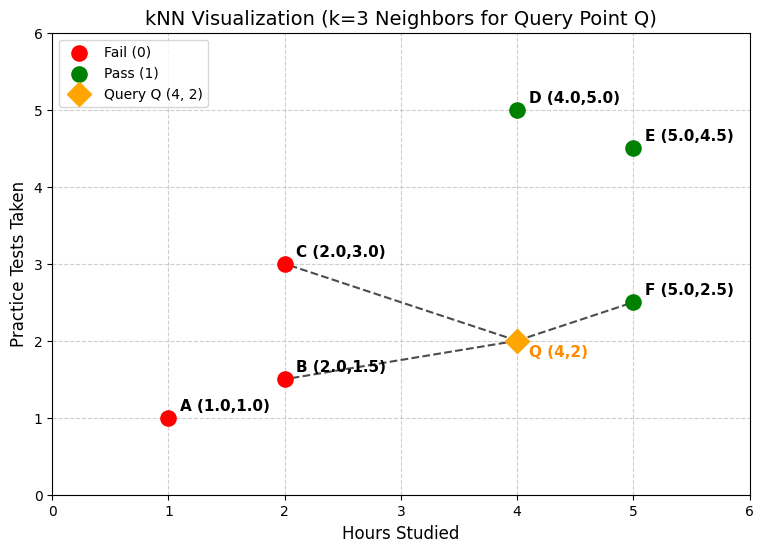

In [83]:
plt.figure(figsize=(9, 6))

# Plot training points
plt.scatter(X_train[Y_train==0, 0], X_train[Y_train==0, 1], color='red', s=120, label='Fail (0)', zorder=3)
plt.scatter(X_train[Y_train==1, 0], X_train[Y_train==1, 1], color='green', s=120, label='Pass (1)', zorder=3)

# Annotate training points
for i, name in enumerate(student_names):
    plt.annotate(f"{name} ({X_train[i][0]},{X_train[i][1]})", (X_train[i][0]+0.1, X_train[i][1]+0.1), fontsize=11, fontweight='bold')

# Plot query point Q
plt.scatter(Q[0], Q[1], color='orange', marker='D', s=150, label='Query Q (4, 2)', zorder=4)
plt.annotate('Q (4,2)', (Q[0]+0.1, Q[1]-0.2), fontsize=11, fontweight='bold', color='darkorange')

# Draw lines to k=3 nearest neighbors (F, B, C)
top3 = sorted_distances[:3]
for item in top3:
    plt.plot([Q[0], item['Hours']], [Q[1], item['Tests']], 'k--', alpha=0.7, linewidth=1.5)

plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Practice Tests Taken', fontsize=12)
plt.title('kNN Visualization (k=3 Neighbors for Query Point Q)', fontsize=14)
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

---


### **B.6 Create the Complete kNN Algorithm**

**Task:** Combine steps into a single function `knn_predict(X_train, y_train, query, k)`.

In [92]:
def knn_predict(X_train, y_train, query, k):
    # 1. Calculate distances from query to all training points
    distances = [np.sqrt(np.sum((x - query) ** 2)) for x in X_train]
    
    # 2 & 3. Sort distances and get indices of k nearest neighbors
    k_indices = np.argsort(distances)[:k]
    
    # 4. Obtain their labels
    k_nearest_labels = y_train[k_indices]
    
    # 5. Perform majority voting
    counts = np.bincount(k_nearest_labels)
    predicted_class = np.argmax(counts)
    
    # 6. Return predicted class
    return predicted_class

# Test the function for Q(4,2) with k=3
test_pred = knn_predict(X_train, Y_train, Q, k=3)
print(f"knn_predict(X_train, Y_train, Q=(4,2), k=3) -> Predicted Class: {test_pred} ({'Pass' if test_pred==1 else 'Fail'})")

knn_predict(X_train, Y_train, Q=(4,2), k=3) -> Predicted Class: 0 (Fail)


---


### **B.7 Verify kNN Using Scikit-learn**

**Task:**
1. Train `KNeighborsClassifier` using the same dataset.
2. Set `n_neighbors = 3`.
3. Predict class of Q = (4, 2).
4. Compare prediction with from-scratch implementation.

In [96]:
from sklearn.neighbors import KNeighborsClassifier

# 1 & 2. Initialize and train KNeighborsClassifier with k=3
knn_sk = KNeighborsClassifier(n_neighbors=3)
knn_sk.fit(X_train, Y_train)

# 3. Predict for Q=(4,2)
sk_pred = knn_sk.predict([Q])[0]

print(f"Scikit-Learn kNN Prediction (k=3) : {sk_pred} ({'Pass' if sk_pred==1 else 'Fail'})")
print(f"From-Scratch kNN Prediction (k=3) : {test_pred} ({'Pass' if test_pred==1 else 'Fail'})")
print(f"Match: {sk_pred == test_pred}")

Scikit-Learn kNN Prediction (k=3) : 0 (Fail)
From-Scratch kNN Prediction (k=3) : 0 (Fail)
Match: True


---


### **B.8 Why Feature Scaling Matters for kNN**

**Task:**
Consider two features: Age (18–70) and Annual Income (20,000–500,000).
1. Which feature would dominate Euclidean distance?
2. Why could this produce misleading nearest neighbors?
3. Which preprocessing technique can reduce this problem?
4. Standardize kNN input features and repeat prediction.

In [107]:
from sklearn.preprocessing import StandardScaler

# 4. Standardize kNN input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
Q_scaled = scaler.transform([Q])[0]

pred_scaled = knn_predict(X_train_scaled, Y_train, Q_scaled, k=3)

print("Standardized Training Features:")
for i, name in enumerate(student_names):
    print(f"  Student {name}: {X_train_scaled[i].round(4)}")
print(f"Standardized Query Q: {Q_scaled.round(4)}")
print(f"Standardized kNN Prediction (k=3): {pred_scaled} ({'Pass' if pred_scaled==1 else 'Fail'})")

Standardized Training Features:
  Student A: [-1.378 -1.317]
  Student B: [-0.742  -0.9734]
  Student C: [-0.742   0.0573]
  Student D: [0.53   1.4315]
  Student E: [1.166  1.0879]
  Student F: [ 1.166  -0.2863]
Standardized Query Q: [ 0.53   -0.6299]
Standardized kNN Prediction (k=3): 0 (Fail)


---
---
---